In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Ising_2d import *
import os

In [96]:
L = 10
h = 0.0
mc_steps = 30000

In [97]:
temp = np.linspace(2.269, 5, 10)
temp_n = [temp[0], temp[-7], temp[-3], temp[-1]]
temp_n

[2.269, 3.179333333333333, 4.393111111111111, 5.0]

In [98]:
temp = [2.269]

for T in temp:
    beta = 1/T
    initial_stat = initial_state(L)
    states = np.zeros((mc_steps, L, L))
    energy = np.zeros(mc_steps)
    magnitizatio = np.zeros(mc_steps)

    for step in range(mc_steps):
        state = montecarlo(initial_stat, L, h, beta)
        initial_stat = np.copy(state)
        states[step] = state
        energy[step] = energy_calculator(state, L, h) / (L**2)
        magnitizatio[step] = magnetization(state) / (L**2)

    parent_dir = "Data2"
    subfolder = os.path.join(parent_dir, f"L_{L}", f"T_{T}")
    os.makedirs(subfolder, exist_ok=True)

    output_file = os.path.join(subfolder, "states.npy")
    output_file_energy = os.path.join(subfolder, "energy.npy")
    output_file_magnitizatio = os.path.join(subfolder, "magnitization.npy")
    np.save(output_file, states)
    np.save(output_file_energy, energy)
    np.save(output_file_magnitizatio, magnitizatio)

In [100]:
np.mean(energy[10000:]), np.mean(np.abs(magnitizatio[10000:])), np.mean(np.abs(magnitizatio[10000:])**2)

(-1.473904, 0.756188, 0.61128104)

In [250]:
(-1.4811586666666667, 0.7609899999999999, 0.6177487866666665)

(-1.4811586666666667, 0.7609899999999999, 0.6177487866666665)

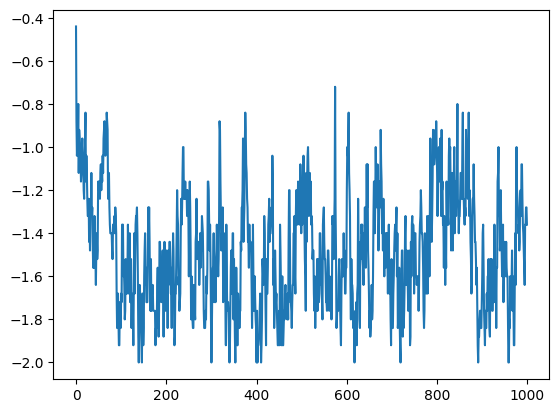

In [6]:
plt.plot(energy[0:1000])

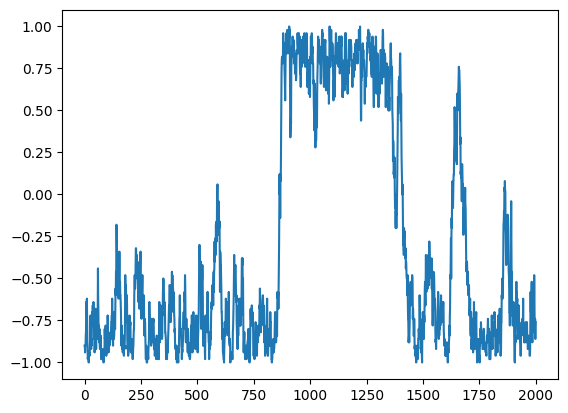

In [7]:
plt.plot(magnitizatio[10000:12000])

In [127]:
def remove_identical_states(states):
    unique_hashes = set()
    unique_states = []

    for state in states:
        state_hash = hash(state.tobytes())
        if state_hash not in unique_hashes:
            unique_hashes.add(state_hash)
            unique_states.append(state)

    return np.array(unique_states)

unique_states = remove_identical_states(states)
len(unique_states), len(states)

(750, 750)